# **Reconocimiento de Patrones**

## **Práctica 1: Preprocesamiento de datos y extracción de características**

**Nombre:** Pérez Aguiar Oropeza Gabriel Emiliano

## 1. Análisis de correlación en el conjunto de datos de la flor Iris

In [6]:
# Bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

### 1.1. Carga del conjunto de datos de la flor Iris

In [4]:
data = load_iris(as_frame=True)
df = data.frame

display(df.head(5))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### 1.2 Selección de las 4 variables numéricas

In [5]:
variables = df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]

display(variables.head(3))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


### 1.3 Cálculo de la matriz de correlación entre estas variables

In [7]:
corr_matrix = (variables).corr(method='pearson')

print(corr_matrix)

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


### 1.4 Visualización de las correlaciones con un mapa de calor

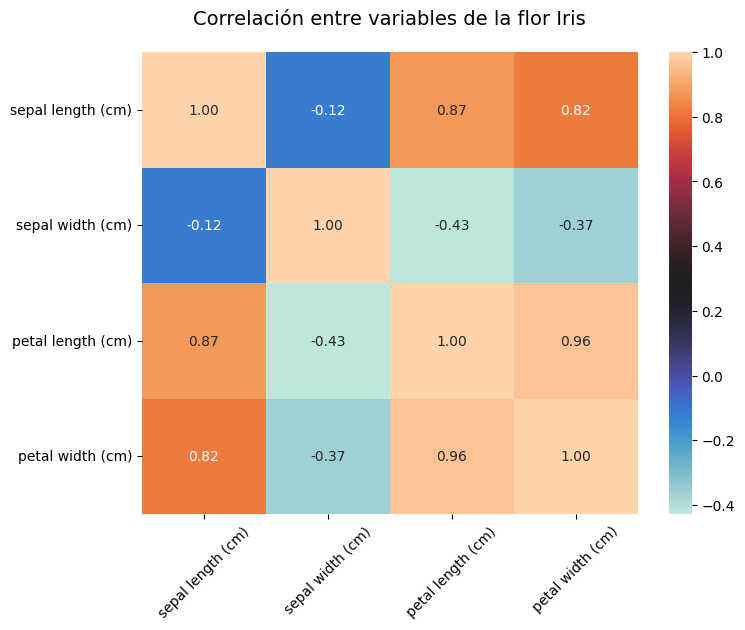

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='icefire' , fmt=".2f")
plt.title('Correlación entre variables de la flor Iris', fontsize=14, pad=20)
plt.xticks(rotation=45)
plt.show()

## 2. Extracción de características en imágenes

In [9]:
# Se instaló la biblioteca scikit-image para procesamiento de imágenes
!pip install scikit-image

  Using cached scikit_image-0.26.0-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (15 kB)
Using cached scikit_image-0.26.0-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (13.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.6/317.6 kB 20.2 kB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.0/244.0 kB 21.3 kB/s eta 0:00:00a 0:00:01


In [10]:
# Bibliotecas necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, util
from skimage.measure import label, regionprops

### 2.1. Carga de una imagen

Tamaño de la imagen:  (600, 600, 3)


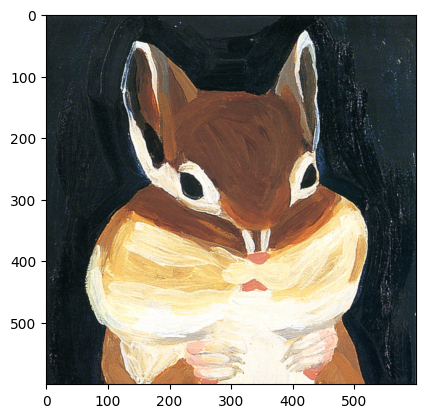

In [11]:
img = cv2.imread('polaris.jpeg')[:, :, ::-1]

print('Tamaño de la imagen: ', img.shape)
plt.imshow(img)
plt.show()

### 2.2. Preprocesamiento de la imagen

Tamaño de la imagen (ya no debe tener 3 dimensiones):  (600, 600)


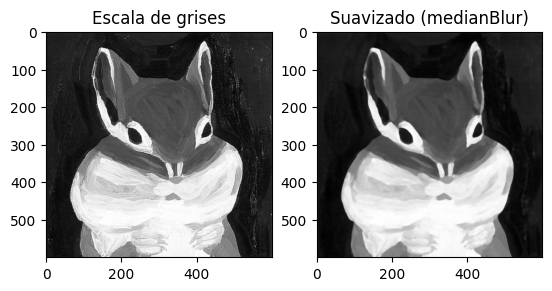

In [12]:
# Conversión a escala de grises
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
print('Tamaño de la imagen (ya no debe tener 3 dimensiones): ', gray.shape)

# Aplicación de filtro de suavizado (medianBlur)
smoothed = cv2.medianBlur(gray, 7)

# Visualización
fig, axes = plt.subplots(1, 2)
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Escala de grises')
axes[1].imshow(smoothed, cmap='gray')
axes[1].set_title('Suavizado (medianBlur)')
plt.show()

### 2.3. Extracción de bordes

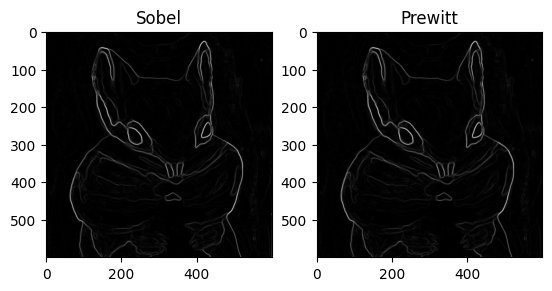

In [13]:
# Conversión de imagen a float (0-1.0) para procesamiento con scikit-image
smoothed_sk = util.img_as_float(smoothed)

# Aplicación de filtros (sobel y prewitt)
sobel = filters.sobel(smoothed_sk)
prewitt = filters.prewitt(util.img_as_float(smoothed_sk))

# Visualización
fig, axes = plt.subplots(1, 2)
axes[0].imshow(sobel, cmap='gray')
axes[0].set_title('Sobel')
axes[1].imshow(prewitt, cmap='gray')
axes[1].set_title('Prewitt')
plt.show()

### 2.4. Detección de círculos utilizando descriptores de forma (HoughCircles)

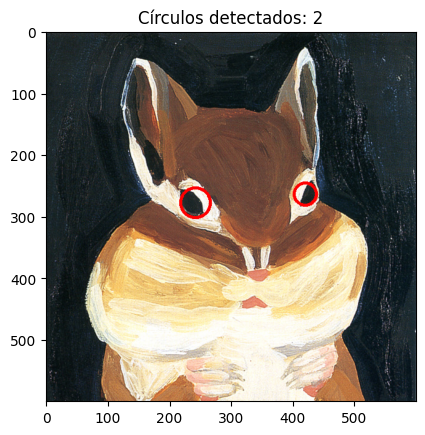

In [14]:
# Conversión de imagen a uint8 (0-255) para procesamiento con OpenCV
edges = (sobel * 255).astype(np.uint8)

# Detección de círculos
circles = cv2.HoughCircles(edges, cv2.HOUGH_GRADIENT, dp=1,
                           minDist=40, param1=50, param2=25, 
                           minRadius=15, maxRadius=30)

# Visualización de los círculos detectados
display = img.copy()
circles = np.round(circles[0, :]).astype("int")

for (x, y, r) in circles:
    cv2.circle(display, (x, y), r, (255, 0, 0), 3)

plt.imshow(display)
plt.title(f'Círculos detectados: {len(circles)}')
plt.show()

### 2.5 Extracción de propiedades de regiones con region props

In [18]:
# Antes de usar regionprops, se debe etiquetar la imagen
label_img = label(edges > 0)

# Extracción de propiedades
props = regionprops(label_img)

# Propiedades de las primeras 3 regiones
print(f"Se encontraron {len(props)} regiones.\n")

for i, region in enumerate(props[:3]):
    row, col = region.centroid
    print(f"Región {i+1}:")
    print(f"  Área: {float(region.area):.2f}")
    print(f"  Perímetro: {region.perimeter:.2f}")
    print("-" * 40)

Se encontraron 1251 regiones.

Región 1:
  Área: 215368.00
  Perímetro: 83177.87
----------------------------------------
Región 2:
  Área: 55.00
  Perímetro: 50.28
----------------------------------------
Región 3:
  Área: 1.00
  Perímetro: 0.00
----------------------------------------


## 3. Generación de señales sintécticas de ECG

In [19]:
# Se instaló la biblioteca NeuroKit2 para generar señales ECG
!pip install neurokit2

  Using cached neurokit2-0.2.13-py3-none-any.whl.metadata (27 kB)
  Using cached pywavelets-1.9.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (7.6 kB)
Using cached neurokit2-0.2.13-py3-none-any.whl (688 kB)
Using cached pywavelets-1.9.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (4.5 MB)


In [20]:
# Bibliotecas necesarias
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt

### 1. Generación de una señal sintética de ECG

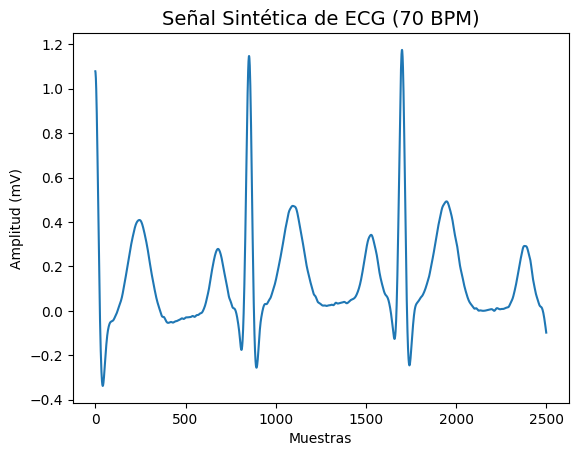

In [21]:
# ecg_simulate genera automáticamente las ondas P, QRS y T
ecg = nk.ecg_simulate(duration=10, sampling_rate=1000, heart_rate=70)

# Visualización de la señal
plt.plot(ecg[:2500])
plt.title('Señal Sintética de ECG (70 BPM)', fontsize=14)
plt.xlabel('Muestras')
plt.ylabel('Amplitud (mV)')
plt.show()

### 2. Simulación de ruido en la señal


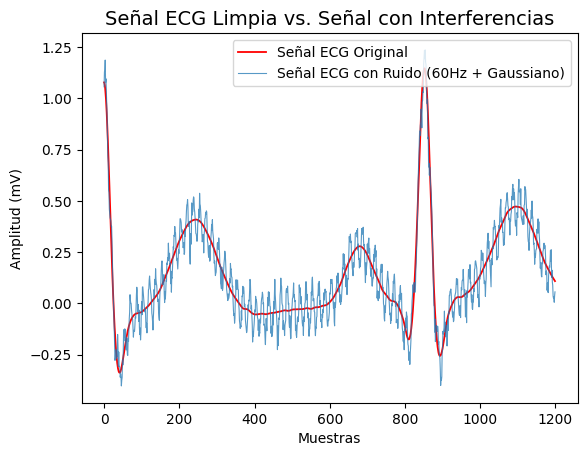

In [22]:
# Ruido de alta frecuencia (60 Hz)
_60hz = nk.signal_simulate(duration=10, sampling_rate=1000, 
                           frequency=60, amplitude=0.1)

# Ruido aleatorio (ruido blanco gaussiano)
white_noise = np.random.normal(0, 0.03, len(ecg))

# Combinación de la señal más el ruido
ecg_final = ecg + _60hz + white_noise

# Visualización de la nueva señal
plt.plot(ecg[:1200], label='Señal ECG Original', color='red', lw=1.3)
plt.plot(ecg_final[:1200], label='Señal ECG con Ruido (60Hz + Gaussiano)', lw=0.8, alpha=0.75)
plt.title('Señal ECG Limpia vs. Señal con Interferencias', fontsize=14)
plt.legend()
plt.xlabel('Muestras')
plt.ylabel('Amplitud (mV)')
plt.show()

### 3. Aplicación de la Transformada de Fourier para analizar el espectro de frecuencia

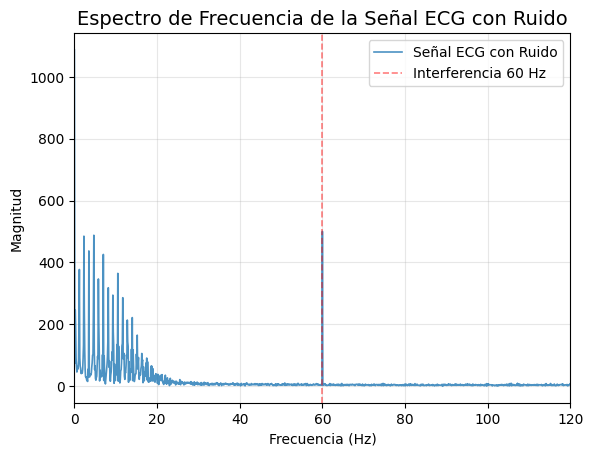

In [23]:
freqs = np.fft.rfftfreq(len(ecg), d=1/1000)
fft = np.abs(np.fft.rfft(ecg_final))

# Visualización del Espectro de Frecuencia
plt.plot(freqs, fft, lw=1.2, label='Señal ECG con Ruido', alpha=0.8)
plt.axvline(x=60, color='red', linestyle='--', alpha=0.5, lw=1.2, label='Interferencia 60 Hz')
plt.title('Espectro de Frecuencia de la Señal ECG con Ruido', fontsize=14)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.xlim(0, 120)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

### 4. Creación de un filtro para eliminar el ruido de alta frecuencia

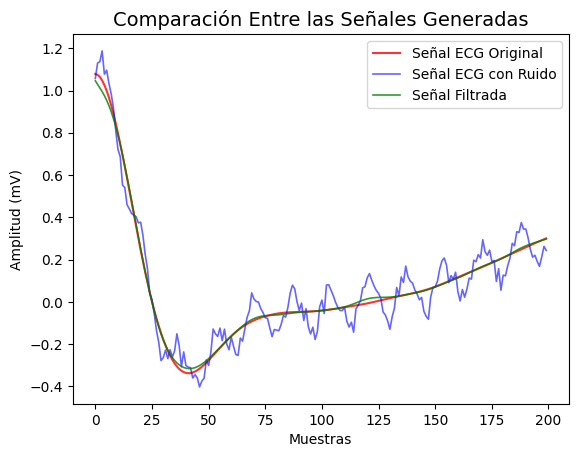

In [24]:
ecg_filter = nk.signal_filter(ecg_final, sampling_rate=1000, highcut=40,
                              method='butterworth', order=5)

# Visualización
plt.plot(ecg[:200], label='Señal ECG Original', color='red', lw=1.5, alpha=0.8)
plt.plot(ecg_final[:200], color='blue', label='Señal ECG con Ruido', lw=1.2, alpha=0.6)
plt.plot(ecg_filter[:200], color='green', label='Señal Filtrada', lw=1.2, alpha=0.8)
plt.title('Comparación Entre las Señales Generadas', fontsize=14)
plt.xlabel('Muestras')
plt.ylabel('Amplitud (mV)')
plt.legend()
plt.show()